In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your NEW Kaggle token: ")

Paste your NEW Kaggle token: ··········


In [ ]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  userRank  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  --------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False         0  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False         0  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False         0  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False         0  
https://www.kaggle.com/compe

In [ ]:
!kaggle competitions download -c data-science-bowl-2018

100% 358M/358M [00:03<00:00, 97.1MB/s]



In [ ]:
!unzip -q /content/data/stage1_train.zip -d /content/data/stage1_train

In [ ]:
TRAIN_PATH = "/content/data/stage1_train"
TEST_PATH = "/content/data/stage1_test"

In [ ]:
image_id = os.listdir(TRAIN_PATH)[0]

image_folder = os.path.join(TRAIN_PATH, image_id, "images")
mask_folder = os.path.join(TRAIN_PATH, image_id, "masks")

print("Image folder:", image_folder)
print("Mask folder:", mask_folder)

print("Image files:", os.listdir(image_folder))
print("Number of masks:", len(os.listdir(mask_folder)))

Image folder: /content/data/stage1_train/d910b2b1be8406caecfe31a503d412ffc4e3d488286242ebc7381836121dd4ef/images
Mask folder: /content/data/stage1_train/d910b2b1be8406caecfe31a503d412ffc4e3d488286242ebc7381836121dd4ef/masks
Image files: ['d910b2b1be8406caecfe31a503d412ffc4e3d488286242ebc7381836121dd4ef.png']
Number of masks: 24


In [ ]:
image_file = os.listdir(image_folder)[0]

image_path = os.path.join(image_folder, image_file)

image = np.array(Image.open(image_path))

print("Shape:", image.shape)
print("Data type:", image.dtype)

Shape: (256, 256, 4)
Data type: uint8


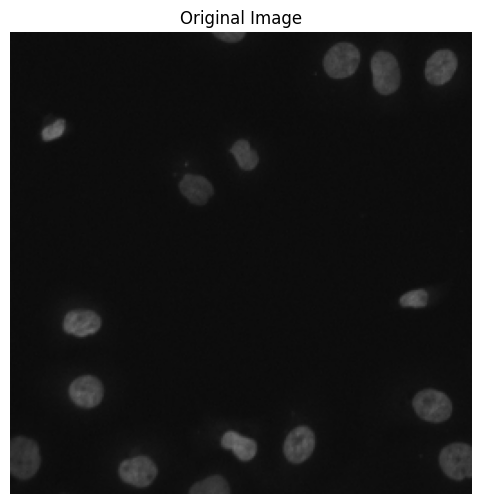

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.axis("off")
plt.title("Original Image")

plt.show()

In [ ]:
import os

os.listdir("/content/data")

['stage1_solution.csv.zip',
 'stage1_train.zip',
 'stage1_test.zip',
 'stage2_test_final.zip',
 'stage2_sample_submission_final.csv.zip',
 'stage1_train_labels.csv.zip',
 'stage1_sample_submission.csv.zip']

In [ ]:
mask_files = os.listdir(mask_folder)

masks = []

for mask_file in mask_files:
    mask_path = os.path.join(mask_folder, mask_file)

    mask = np.array(Image.open(mask_path))
    masks.append(mask)

print("Number of masks:", len(masks))
print("Shape of first mask:", masks[0].shape)

Number of masks: 24
Shape of first mask: (256, 256)


In [ ]:
combined_mask = np.zeros_like(masks[0], dtype=np.uint8)

for mask in masks:
    combined_mask = np.maximum(combined_mask, mask)

In [ ]:
combined_mask = (combined_mask > 0).astype(np.uint8)

print(np.unique(combined_mask))

[0 1]


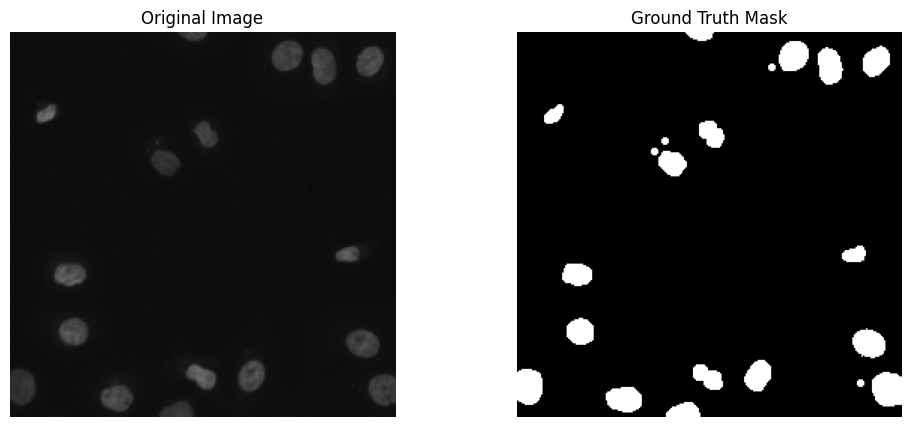

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(combined_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

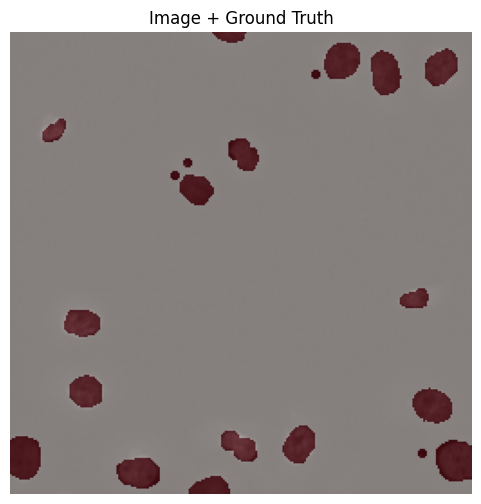

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.imshow(combined_mask, alpha=0.5, cmap="Reds")

plt.axis("off")
plt.title("Image + Ground Truth")

plt.show()

In [ ]:
def load_image_and_mask(image_id, base_path):

    # Image directory
    image_folder = os.path.join(
        base_path,
        image_id,
        "images"
    )

    # Mask directory
    mask_folder = os.path.join(
        base_path,
        image_id,
        "masks"
    )

    # Load image
    image_file = os.listdir(image_folder)[0]

    image = np.array(
        Image.open(
            os.path.join(image_folder, image_file)
        ).convert("RGB")
    )

    # Create empty mask
    mask = np.zeros(
        image.shape[:2],
        dtype=np.uint8
    )

    # Combine individual masks
    for mask_file in os.listdir(mask_folder):

        current_mask = np.array(
            Image.open(
                os.path.join(mask_folder, mask_file)
            )
        )

        mask = np.maximum(mask, current_mask)

    # Convert to binary
    mask = (mask > 0).astype(np.uint8)

    return image, mask

In [ ]:
image, mask = load_image_and_mask(
    image_id,
    TRAIN_PATH
)

print(image.shape)
print(mask.shape)

(256, 256, 3)
(256, 256)


In [ ]:
image_ids = os.listdir(TRAIN_PATH)

print("Total images:", len(image_ids))

Total images: 670


In [ ]:
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_ids))
print("Validation images:", len(val_ids))

Training images: 536
Validation images: 134


In [ ]:
class NucleiDataset(Dataset):

    def __init__(self, image_ids, base_path, image_size=(256, 256)):

        self.image_ids = image_ids
        self.base_path = base_path
        self.image_size = image_size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):

        image_id = self.image_ids[index]

        image, mask = load_image_and_mask(
            image_id,
            self.base_path
        )

        # Convert to PIL for resizing
        image = Image.fromarray(image)
        mask = Image.fromarray(mask)

        # Resize
        image = image.resize(
            self.image_size,
            Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            self.image_size,
            Image.Resampling.NEAREST
        )

        # Convert to numpy
        image = np.array(image)
        mask = np.array(mask)

        # Normalize image
        image = image / 255.0

        # H,W,C → C,H,W
        image = np.transpose(
            image,
            (2, 0, 1)
        )

        # Convert to tensors
        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        # Add channel dimension
        mask = mask.unsqueeze(0)

        return image, mask

In [ ]:
train_dataset = NucleiDataset(
    train_ids,
    TRAIN_PATH
)

val_dataset = NucleiDataset(
    val_ids,
    TRAIN_PATH
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 536
Validation: 134


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

In [ ]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: torch.Size([8, 3, 256, 256])
Masks: torch.Size([8, 1, 256, 256])


In [ ]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Pooling
        self.pool = nn.MaxPool2d(2)

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024, 512, kernel_size=2, stride=2
        )
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(128, 64)

        # Final output
        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)
model = UNet().to(device)

print(model)

Using: cuda
UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, 

In [ ]:
def dice_loss(pred, target, smooth=1):

    pred = torch.sigmoid(pred)

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    dice = (
        (2.0 * intersection + smooth)
        /
        (pred.sum() + target.sum() + smooth)
    )

    return 1 - dice

In [ ]:
bce = nn.BCEWithLogitsLoss()

def loss_function(pred, target):

    return (
        bce(pred, target)
        +
        dice_loss(pred, target)
    )

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        predictions = model(images)

        # Calculate loss
        loss = loss_function(
            predictions,
            masks
        )

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {train_loss:.4f}"
    )

Epoch [1/20] Loss: 0.9450
Epoch [2/20] Loss: 0.7056
Epoch [3/20] Loss: 0.6253
Epoch [4/20] Loss: 0.5714
Epoch [5/20] Loss: 0.5243
Epoch [6/20] Loss: 0.5098
Epoch [7/20] Loss: 0.4465
Epoch [8/20] Loss: 0.4189
Epoch [9/20] Loss: 0.3904
Epoch [10/20] Loss: 0.3639
Epoch [11/20] Loss: 0.3371
Epoch [12/20] Loss: 0.3140
Epoch [13/20] Loss: 0.3012
Epoch [14/20] Loss: 0.2872
Epoch [15/20] Loss: 0.2843
Epoch [16/20] Loss: 0.2674
Epoch [17/20] Loss: 0.2566
Epoch [18/20] Loss: 0.2453
Epoch [19/20] Loss: 0.2336
Epoch [20/20] Loss: 0.2241


In [ ]:
def dice_score(pred, target, threshold=0.5):

    pred = torch.sigmoid(pred)

    pred = (pred > threshold).float()

    intersection = (pred * target).sum()

    dice = (
        2 * intersection
        /
        (pred.sum() + target.sum() + 1e-8)
    )

    return dice.item()

In [ ]:
model.eval()

total_dice = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)

        total_dice += dice_score(
            predictions,
            masks
        )

average_dice = total_dice / len(val_loader)

print("Validation Dice:", average_dice)

Validation Dice: 0.9022738477763008


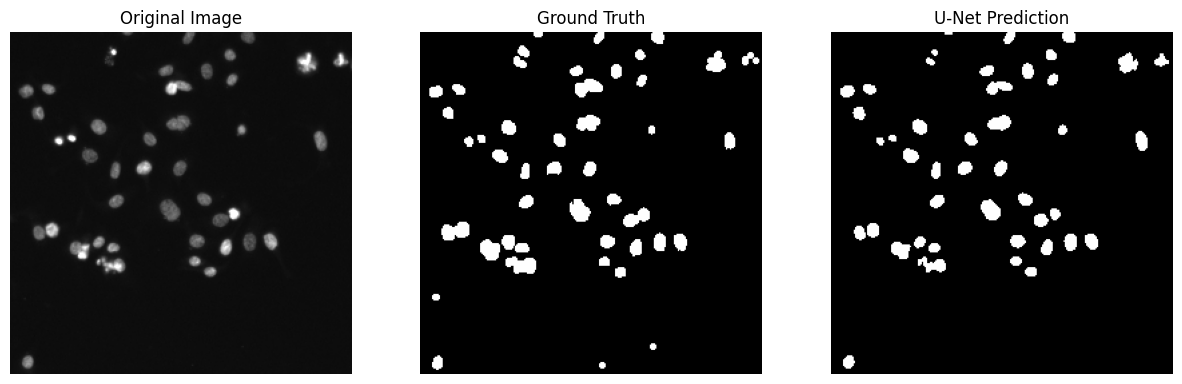

In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():
    predictions = model(images)

predictions = torch.sigmoid(predictions)

pred_mask = predictions[0][0].cpu().numpy()

original_image = images[0].cpu().permute(1, 2, 0).numpy()
true_mask = masks[0][0].numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask > 0.5, cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.show()